## Creating a combined supervised Model best of both worlds

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

In [2]:
# Shared Data Prep

# Load features
features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.sort_values("date").set_index("date")

# Lagged predictors
for i in range(1, 6):
    features_df[f"SPY_return_lag{i}"] = features_df["SPY_return"].shift(i)
    features_df[f"VIX_change_lag{i}"] = features_df["VIX_change"].shift(i)
    features_df[f"yield_spread_lag{i}"] = features_df["yield_spread"].shift(i)

# Optional: transition-sensitive features
features_df["SPY_vol_ratio"] = features_df["SPY_vol_4"] / features_df["SPY_vol_12"]
features_df["SPY_vol_spread"] = features_df["SPY_vol_4"] - features_df["SPY_vol_12"]
features_df["SPY_return_rolling_4"] = features_df["SPY_return"].rolling(4).mean()
features_df["QQQ_return_rolling_4"] = features_df["QQQ_return"].rolling(4).mean()

# Shared predictive feature set
predict_cols = [
    "SPY_return",
    "QQQ_return",
    "SPY_momentum_12",
    "VIX_change",
    "SPY_vol_4",
    "SPY_vol_12",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "SPY_return_lag3",
    "SPY_return_lag4",
    "SPY_return_lag5",
    "VIX_change_lag1",
    "VIX_change_lag2",
    "VIX_change_lag3",
    "VIX_change_lag4",
    "VIX_change_lag5",
    "yield_spread_lag1",
    "yield_spread_lag2",
    "yield_spread_lag3",
    "yield_spread_lag4",
    "yield_spread_lag5",
    "SPY_vol_ratio",
    "SPY_vol_spread",
    "SPY_return_rolling_4",
    "QQQ_return_rolling_4",
]

# Load regime labels
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet").sort_index()

# Align datasets
common_idx = features_df.index.intersection(regime_df.index)
features_df = features_df.loc[common_idx].copy()
regime_df = regime_df.loc[common_idx].copy()

# Map regime names
regime_map = {
    0: "Low_Vol",
    1: "Mid_Vol",
    2: "High_Vol"
}
reg_cols = ["Low_Vol", "Mid_Vol", "High_Vol"]

regime_df["current_regime"] = regime_df["regime_3class"].map(regime_map)
regime_df["target_regime"] = regime_df["regime_3class"].shift(-1)
regime_df["next_regime"] = regime_df["target_regime"].map(regime_map)

# Updated Layer 1 target: risk vs calm
regime_df["target_risk"] = np.where(
    regime_df["next_regime"].isin(["Mid_Vol", "High_Vol"]),
    "risk",
    "calm"
)
regime_df.loc[regime_df["next_regime"].isna(), "target_risk"] = np.nan

# Retain the original change target for model comparison
regime_df["target_change"] = np.where(
    regime_df["next_regime"] != regime_df["current_regime"],
    "change",
    "no change"
)
regime_df.loc[regime_df["next_regime"].isna(), "target_change"] = np.nan

# Build final master modeling frame
model_df = features_df[predict_cols].copy()
model_df["current_regime"] = regime_df["current_regime"]
model_df["next_regime"] = regime_df["next_regime"]
model_df["target_risk"] = regime_df["target_risk"]
model_df["target_change"] = regime_df["target_change"]

model_df = model_df.dropna().copy()

print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Current regime counts:")
print(model_df["current_regime"].value_counts())
print()
print("Next regime counts:")
print(model_df["next_regime"].value_counts())
print()
print("Risk target counts:")
print(model_df["target_risk"].value_counts())
print()
print("Change target counts:")
print(model_df["target_change"].value_counts())
print()

Modeling rows: 1,049
Date range: 2004-12-31 to 2026-02-13

Current regime counts:
current_regime
Low_Vol     745
Mid_Vol     270
High_Vol     34
Name: count, dtype: int64

Next regime counts:
next_regime
Low_Vol     745
Mid_Vol     270
High_Vol     34
Name: count, dtype: int64

Risk target counts:
target_risk
calm    745
risk    304
Name: count, dtype: int64

Change target counts:
target_change
no change    991
change        58
Name: count, dtype: int64



In [3]:
# Shared splits
TRAIN_END = "2016-12-31"
VAL_END   = "2019-12-31"


train = model_df.loc[:TRAIN_END].copy()
val = model_df.loc[(model_df.index > TRAIN_END) & (model_df.index <= VAL_END)].copy()
test = model_df.loc[model_df.index > VAL_END].copy()

print(f"Training rows:   {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Validation rows: {len(val):,} ({val.index.min().date()} to {val.index.max().date()})")
print(f"Testing rows:    {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, df_ in [("Train", train), ("Validation", val), ("Test", test)]:

    print(f"{split_name} current_regime counts:")
    print(df_["current_regime"].value_counts())
    print()

    print(f"{split_name} next_regime counts:")
    print(df_["next_regime"].value_counts())
    print()
    
    print(f"{split_name} target_risk counts:")
    print(df_["target_risk"].value_counts())
    print()

Training rows:   593 (2004-12-31 to 2016-12-30)
Validation rows: 148 (2017-01-06 to 2019-12-27)
Testing rows:    308 (2020-01-03 to 2026-02-13)

Train current_regime counts:
current_regime
Low_Vol     406
Mid_Vol     165
High_Vol     22
Name: count, dtype: int64

Train next_regime counts:
next_regime
Low_Vol     406
Mid_Vol     165
High_Vol     22
Name: count, dtype: int64

Train target_risk counts:
target_risk
calm    406
risk    187
Name: count, dtype: int64

Validation current_regime counts:
current_regime
Low_Vol    130
Mid_Vol     18
Name: count, dtype: int64

Validation next_regime counts:
next_regime
Low_Vol    130
Mid_Vol     18
Name: count, dtype: int64

Validation target_risk counts:
target_risk
calm    130
risk     18
Name: count, dtype: int64

Test current_regime counts:
current_regime
Low_Vol     209
Mid_Vol      87
High_Vol     12
Name: count, dtype: int64

Test next_regime counts:
next_regime
Low_Vol     209
Mid_Vol      87
High_Vol     12
Name: count, dtype: int64

Test

In [4]:
# Baselines

# Direct multiclass persistence
persist_val_reg = val["current_regime"].copy()
persist_test_reg = test["current_regime"].copy()

# Majority baseline for direct next-regime model
majority_direct = train["next_regime"].value_counts().idxmax()
majority_direct_val = pd.Series(majority_direct, index=val.index)
majority_direct_test = pd.Series(majority_direct, index=test.index)

# Majority baseline for Layer 1 risk model
majority_risk = train["target_risk"].value_counts().idxmax()
majority_risk_val = pd.Series(majority_risk, index=val.index)
majority_risk_test = pd.Series(majority_risk, index=test.index)

print("Direct majority baseline regime:", majority_direct)
print("Layer 1 majority baseline:", majority_risk)
print()

Direct majority baseline regime: Low_Vol
Layer 1 majority baseline: calm



In [5]:
# Arun model - direct next regime prediction
print("=" * 75)
print("ARUN MODEL - Direct multiclass next regime prediction")
print("=" * 75)

X_train_arun = train[predict_cols]
X_val_arun = val[predict_cols]
X_test_arun = test[predict_cols]

y_train_arun = train["next_regime"]
y_val_arun = val["next_regime"]
y_test_arun = test["next_regime"]

# Scaling for logistic regression
scaler_arun = StandardScaler()
X_train_arun_sc = scaler_arun.fit_transform(X_train_arun)
X_val_arun_sc = scaler_arun.transform(X_val_arun)
X_test_arun_sc = scaler_arun.transform(X_test_arun)

# Logistic Regression
lr_arun = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)
lr_arun.fit(X_train_arun_sc, y_train_arun)

arun_lr_val_pred = lr_arun.predict(X_val_arun_sc)
arun_lr_test_pred = lr_arun.predict(X_test_arun_sc)

print("ARUN LOGISTIC REGRESSION - Validation")
print(classification_report(y_val_arun, arun_lr_val_pred, labels=reg_cols, digits=3, zero_division=0))
print("Validation accuracy:", round(accuracy_score(y_val_arun, arun_lr_val_pred), 4))
print()

print("ARUN LOGISTIC REGRESSION - Test")
print(classification_report(y_test_arun, arun_lr_test_pred, labels=reg_cols, digits=3, zero_division=0))
print("Test accuracy:", round(accuracy_score(y_test_arun, arun_lr_test_pred), 4))
print()

ARUN MODEL - Direct multiclass next regime prediction
ARUN LOGISTIC REGRESSION - Validation
              precision    recall  f1-score   support

     Low_Vol      0.984     0.938     0.961       130
     Mid_Vol      0.619     0.722     0.667        18
    High_Vol      0.000     0.000     0.000         0

    accuracy                          0.912       148
   macro avg      0.534     0.554     0.542       148
weighted avg      0.940     0.912     0.925       148

Validation accuracy: 0.9122

ARUN LOGISTIC REGRESSION - Test
              precision    recall  f1-score   support

     Low_Vol      0.923     0.923     0.923       209
     Mid_Vol      0.775     0.632     0.696        87
    High_Vol      0.357     0.833     0.500        12

    accuracy                          0.838       308
   macro avg      0.685     0.796     0.707       308
weighted avg      0.859     0.838     0.843       308

Test accuracy: 0.8377



In [6]:
# Arun model - direct next regime prediction

# Random Forest
rf_arun = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_arun.fit(X_train_arun, y_train_arun)

arun_rf_val_pred = rf_arun.predict(X_val_arun)
arun_rf_test_pred = rf_arun.predict(X_test_arun)

print("ARUN RANDOM FOREST - Validation")
print(classification_report(y_val_arun, arun_rf_val_pred, labels=reg_cols, digits=3, zero_division=0))
print("Validation accuracy:", round(accuracy_score(y_val_arun, arun_rf_val_pred), 4))
print()

print("ARUN RANDOM FOREST - Test")
print(classification_report(y_test_arun, arun_rf_test_pred, labels=reg_cols, digits=3, zero_division=0))
print("Test accuracy:", round(accuracy_score(y_test_arun, arun_rf_test_pred), 4))
print()

ARUN RANDOM FOREST - Validation
              precision    recall  f1-score   support

     Low_Vol      0.970     1.000     0.985       130
     Mid_Vol      1.000     0.778     0.875        18
    High_Vol      0.000     0.000     0.000         0

    accuracy                          0.973       148
   macro avg      0.657     0.593     0.620       148
weighted avg      0.974     0.973     0.971       148

Validation accuracy: 0.973

ARUN RANDOM FOREST - Test
              precision    recall  f1-score   support

     Low_Vol      0.795     0.986     0.880       209
     Mid_Vol      0.778     0.402     0.530        87
    High_Vol      1.000     0.333     0.500        12

    accuracy                          0.795       308
   macro avg      0.858     0.574     0.637       308
weighted avg      0.798     0.795     0.767       308

Test accuracy: 0.7955



In [7]:
# Choosing Arun best model by validation accuracy
arun_lr_val_acc = accuracy_score(y_val_arun, arun_lr_val_pred)
arun_rf_val_acc = accuracy_score(y_val_arun, arun_rf_val_pred)

if arun_lr_val_acc >= arun_rf_val_acc:
    arun_best_name = "Logistic Regression"
    arun_val_pred = pd.Series(arun_lr_val_pred, index=val.index)
    arun_test_pred = pd.Series(arun_lr_test_pred, index=test.index)
    arun_best_model = lr_arun
else:
    arun_best_name = "Random Forest"
    arun_val_pred = pd.Series(arun_rf_val_pred, index=val.index)
    arun_test_pred = pd.Series(arun_rf_test_pred, index=test.index)
    arun_best_model = rf_arun

print("Arun model selection:")
print(f"  Logistic Regression val accuracy: {arun_lr_val_acc:.4f}")
print(f"  Random Forest val accuracy:       {arun_rf_val_acc:.4f}")
print(f"Selected Arun model: {arun_best_name}")
print()

Arun model selection:
  Logistic Regression val accuracy: 0.9122
  Random Forest val accuracy:       0.9730
Selected Arun model: Random Forest




Modeling rows: 1,049
Date range: 2004-12-31 to 2026-02-13

Target class counts:
target
no change    991
change        58
Name: count, dtype: int64

Majority baseline accuracy: 0.9088
Training rows: 593 (2004-12-31 to 2016-12-30)
Validation rows:  147 (2017-01-13 to 2019-12-27)
Testing rows:  307 (2020-01-10 to 2026-02-13)

Train class distribution:
target
no change    0.956
change       0.044
Name: proportion, dtype: float64

Validation class distribution:
target
no change    0.973
change       0.027
Name: proportion, dtype: float64

Test class distribution:
target
no change    0.909
change       0.091
Name: proportion, dtype: float64

threshold: 0.05 f1: 0.105 chg: 0.231
threshold: 0.060000000000000005 f1: 0.121 chg: 0.197
threshold: 0.07 f1: 0.174 chg: 0.129
threshold: 0.08000000000000002 f1: 0.235 chg: 0.088
threshold: 0.09000000000000001 f1: 0.154 chg: 0.061
threshold: 0.1 f1: 0.2 chg: 0.041
threshold: 0.11000000000000001 f1: 0.2 chg: 0.041
threshold: 0.12000000000000001 f1: 0.0 c

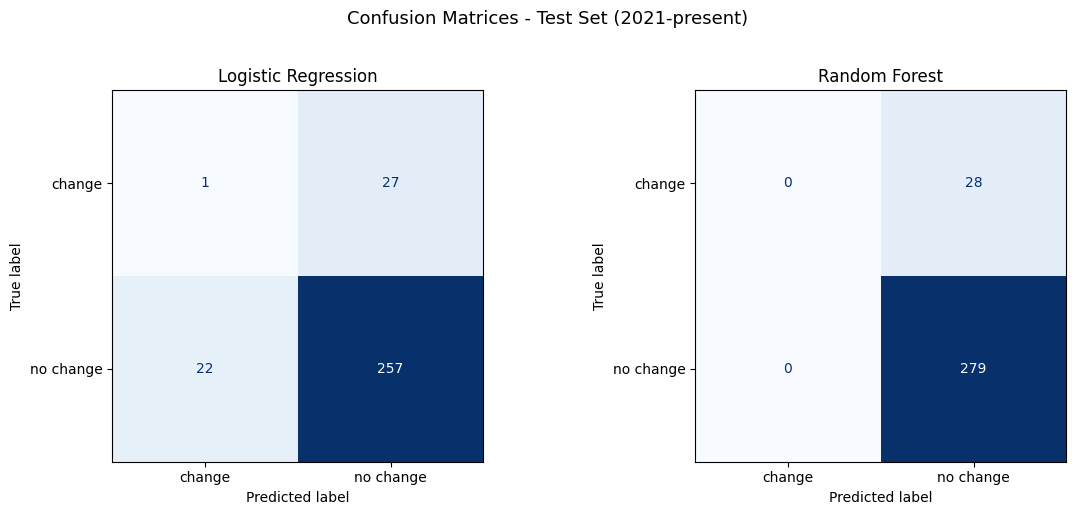

Model summary:
                      Accuracy  Precision (weighted)  Recall (weighted)
Model                                                                  
Majority Baseline       0.9088                0.8259             0.9088
Persistence Baseline    0.9088                0.8259             0.9088
Logistic Regression     0.8404                0.8264             0.8404
Random Forest           0.9088                0.8259             0.9088



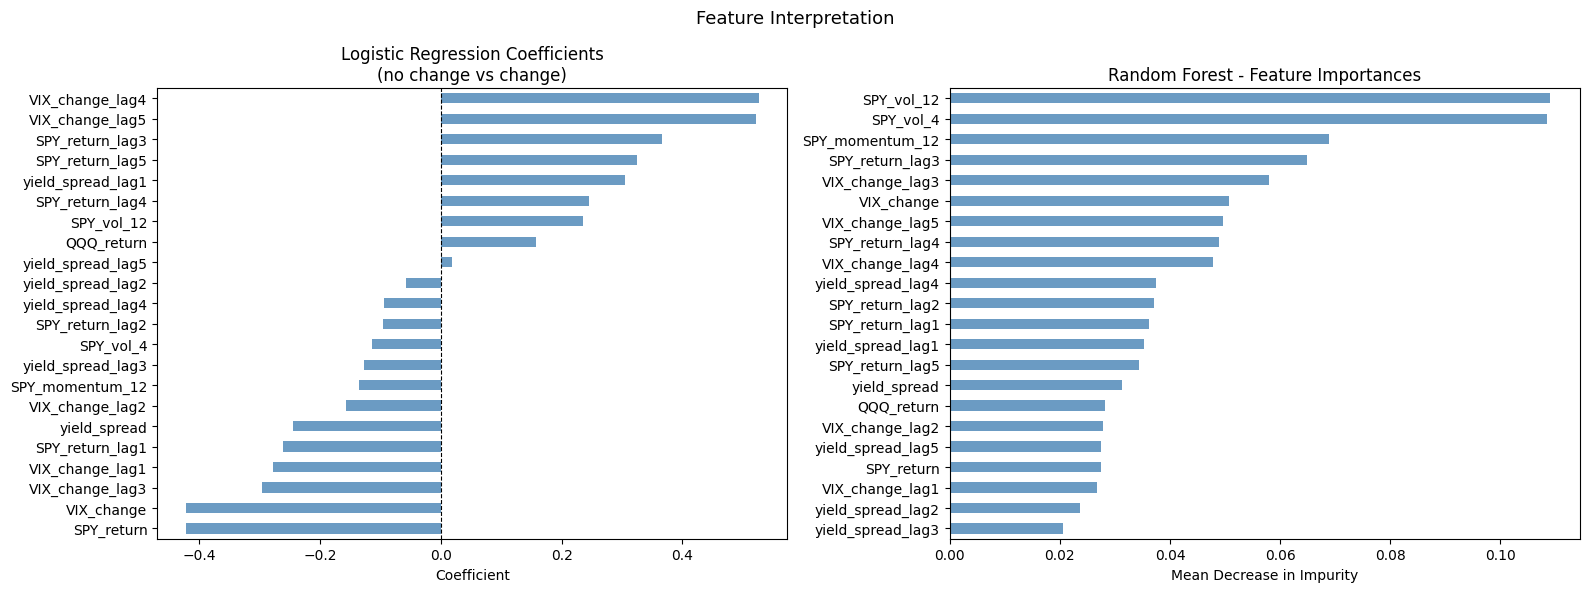

In [8]:
#NEW NEW

#Add validation set to pick model
#Create 2 layer. 1st layer predict % regime will change


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)


# Step 1: Load and prepare features
features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.sort_values("date").set_index("date")

# Lagged predictors
for i in range(1, 6):
    features_df[f"SPY_return_lag{i}"] = features_df["SPY_return"].shift(i)
    features_df[f"VIX_change_lag{i}"] = features_df["VIX_change"].shift(i)
    features_df[f"yield_spread_lag{i}"] = features_df["yield_spread"].shift(i)

# Predictive feature set
predict_cols = [
    "SPY_return",
    "QQQ_return",
    "SPY_momentum_12",
    "VIX_change",
    "SPY_vol_4",
    "SPY_vol_12",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "SPY_return_lag3",
    "SPY_return_lag4",
    "SPY_return_lag5",
    "VIX_change_lag1",
    "VIX_change_lag2",
    "VIX_change_lag3",
    "VIX_change_lag4",
    "VIX_change_lag5",
    "yield_spread_lag1",
    "yield_spread_lag2",
    "yield_spread_lag3",
    "yield_spread_lag4",
    "yield_spread_lag5"
]

# Step 2: Load regime labels
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet").sort_index()

# Align both datasets on common dates
common_idx = features_df.index.intersection(regime_df.index)
features_df = features_df.loc[common_idx].copy()
regime_df = regime_df.loc[common_idx].copy()


# Step 3: Create current regime name from 3-class labels
regime_df["regime_name"] = regime_df["regime_3class"].map({
    0: "Low_Vol",
    1: "Mid_Vol",
    2: "High_Vol"
})

# Next-period target
regime_df["target_regime"] = regime_df["regime_3class"].shift(-1)

regime_df["target_regime_name"] = regime_df["target_regime"].map({
    0: "Low_Vol",
    1: "Mid_Vol",
    2: "High_Vol"
})


regime_df["target_change"] = np.where(regime_df["target_regime_name"] != regime_df["regime_name"],'change','no change')
regime_df.loc[regime_df["target_regime_name"].isna(), "target_change"] = np.nan

class_order = ["change", "no change"]


# Step 4: Build final supervised dataset

model_df = features_df[predict_cols].copy()
current_regime = regime_df["regime_name"].reindex(model_df.index)
next_regime = regime_df["target_regime_name"].reindex(model_df.index)
target = regime_df["target_change"].reindex(model_df.index)
model_df["current_regime"] = current_regime
model_df["next_regime"] = next_regime
model_df["target"] = target

# Drop rows with missing predictors or target
model_df = model_df.dropna().copy()

print()
print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Target class counts:")
print(model_df["target"].value_counts())
print()

TRAIN_END = "2016-12-31"
vald = "2019-12-31"

train = model_df.loc[:TRAIN_END]
val = model_df.loc[TRAIN_END:vald].iloc[1:]
test = model_df.loc[vald:].iloc[1:]

X_train, y_train = train[predict_cols], train["target"]
X_val, y_val = val[predict_cols], val["target"]
X_test, y_test = test[predict_cols], test["target"]

majority_class = y_train.value_counts().idxmax()

majority_pred = pd.Series([majority_class] * len(y_test), index=y_test.index)

majority_acc = accuracy_score(y_test, majority_pred)

print("Majority baseline accuracy:", round(majority_acc, 4))


print(f"Training rows: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Validation rows:  {len(val):,} ({val.index.min().date()} to {val.index.max().date()})")
print(f"Testing rows:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, y in [("Train", y_train), ("Validation", y_val),("Test", y_test)]:
    print(f"{split_name} class distribution:")
    print(y.value_counts(normalize=True).round(3))
    print()



sup_scaler = StandardScaler()
X_train_sc = sup_scaler.fit_transform(X_train)
X_test_sc = sup_scaler.transform(X_test)
X_val_sc = sup_scaler.transform(X_val)


lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
cid = list(lr.classes_).index("change")
pvl = lr.predict_proba(X_val_sc)[:, cid]
pts = lr.predict_proba(X_test_sc)[:, cid]
ths = np.arange(0.05,0.6,0.01)
bst = 0.5
bsc = -1
for i in ths:
    yvl = np.where(pvl >= i, "change", "no change")
    f1 = f1_score(y_val, yvl, pos_label="change")
    rte = (yvl == "change").mean()
    print("threshold:", i, "f1:", round(f1, 3), "chg:", round(rte, 3))
    if rte > 0 and f1 > bsc:
        bsc = f1
        bst = i

print()
print("best threshold:", bst)

y_pred_lr_val = np.where(pvl >= bst, "change", "no change")
y_pred_lr = np.where(pts >= bst, "change", "no change")

print("LOGISTIC REGRESSION - Validation performance")
print(classification_report(y_val, y_pred_lr_val, digits=3, zero_division=0))
print()
print("LOGISTIC REGRESSION - Test performance")
print(classification_report(y_test, y_pred_lr, digits=3, zero_division=0))
print()


per_pred = pd.Series("no change", index=y_test.index)
persistence_acc = accuracy_score(y_test, per_pred)

print("Persistence baseline accuracy:", round(persistence_acc, 4))



rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1, class_weight = 'balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_val = rf.predict(X_val)

print("RANDOM FOREST - Validation performance")
print(classification_report(y_val, y_pred_rf_val, digits=3, zero_division=0))
print()
print("RANDOM FOREST - Test performance")
print(classification_report(y_test, y_pred_rf, digits=3, zero_division=0))
print()

class_order = ["change", "no change"]

models_to_plot = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
]

n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices - Test Set (2021-present)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

rows = []

# Majority baseline
rows.append({
    "Model": "Majority Baseline",
    "Accuracy": round(accuracy_score(y_test, majority_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
})

# Persistence baseline
rows.append({
    "Model": "Persistence Baseline",
    "Accuracy": round(accuracy_score(y_test, per_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, per_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, per_pred, average="weighted", zero_division=0), 4
    ),
})

# ML models
for name, y_pred in models_to_plot:
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (weighted)": round(
            precision_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
        "Recall (weighted)": round(
            recall_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

print("Model summary:")
print(summary_df.to_string())
print()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic regression coefficients
ax0 = axes[0]

if len(lr.classes_) == 2:
    coef_s = pd.Series(
        lr.coef_[0],
        index=predict_cols,
        name=f"{lr.classes_[1]} vs {lr.classes_[0]}"
    ).sort_values()

    coef_s.plot(kind="barh", ax=ax0, color="steelblue", alpha=0.8)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title(f"Logistic Regression Coefficients\n({lr.classes_[1]} vs {lr.classes_[0]})")
    ax0.set_xlabel("Coefficient")
else:
    coef_df = pd.DataFrame(lr.coef_, columns=predict_cols, index=lr.classes_)
    colors = ["steelblue", "darkorange", "green", "purple", "red"]

    feature_order = np.argsort(np.abs(coef_df.values).mean(axis=0))
    ordered_features = np.array(predict_cols)[feature_order]

    for i, cls in enumerate(lr.classes_):
        vals = coef_df.loc[cls, ordered_features]
        ax0.barh(
            np.arange(len(ordered_features)) + i * 0.25,
            vals,
            height=0.25,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=cls
        )

    ax0.set_yticks(np.arange(len(ordered_features)) + 0.25)
    ax0.set_yticklabels(ordered_features, fontsize=9)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title("Logistic Regression Coefficients (per class)")
    ax0.legend(fontsize=9)

# Random forest feature importance
fi = pd.Series(rf.feature_importances_, index=predict_cols).sort_values()
fi.plot(kind="barh", ax=axes[1], color="steelblue", alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.suptitle("Feature Interpretation", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Pick best Layer 1 model using recall-sensitive validation score for "risk"
phuc_l1_lr_val_rec = recall_score(y_val, y_pred_lr_val, pos_label="change", zero_division=0)
phuc_l1_lr_val_prec = precision_score(y_val, y_pred_lr_val, pos_label="change", zero_division=0)
phuc_l1_lr_val_score = 0.7 * phuc_l1_lr_val_rec + 0.3 * phuc_l1_lr_val_prec

phuc_l1_rf_val_rec = recall_score(y_val, y_pred_rf_val, pos_label="change", zero_division=0)
phuc_l1_rf_val_prec = precision_score(y_val, y_pred_rf_val, pos_label="change", zero_division=0)
phuc_l1_rf_val_score = 0.7 * phuc_l1_rf_val_rec + 0.3 * phuc_l1_rf_val_prec

if phuc_l1_lr_val_score >= phuc_l1_rf_val_score:
    phuc_l1_name = "Logistic Regression"
    l1_val_pred = pd.Series(y_pred_lr_val, index=y_val.index)
    l1_test_pred = pd.Series(y_pred_lr, index=y_test.index)
else:
    phuc_l1_name = "Random Forest"
    l1_val_pred = pd.Series(y_pred_rf_val, index=y_val.index)
    l1_test_pred = pd.Series(y_pred_rf, index=y_test.index)


print(f"  Logistic val recall (risk):   {phuc_l1_lr_val_rec:.4f}")
print(f"  Logistic val precision (risk): {phuc_l1_lr_val_prec:.4f}")
print(f"  Logistic val score:            {phuc_l1_lr_val_score:.4f}")
print()
print(f"  RF val recall (risk):          {phuc_l1_rf_val_rec:.4f}")
print(f"  RF val precision (risk):       {phuc_l1_rf_val_prec:.4f}")
print(f"  RF val score:                  {phuc_l1_rf_val_score:.4f}")
print()
print(f"Selected Phuc Layer 1 model: {phuc_l1_name}")
print()

  Logistic val recall (risk):   0.5000
  Logistic val precision (risk): 0.1538
  Logistic val score:            0.3962

  RF val recall (risk):          0.0000
  RF val precision (risk):       0.0000
  RF val score:                  0.0000

Selected Phuc Layer 1 model: Logistic Regression



In [10]:
# NEW NEW NEW

# Layer 2: if change, what is the new regime?

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

predict_cols2 = [
    "SPY_return",
    "QQQ_return",
    "VIX_change",
    "SPY_vol_4",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "VIX_change_lag1",
    "VIX_change_lag2",
    "yield_spread_lag1",
    "yield_spread_lag2"
]

cdf = model_df[model_df["target"] == "change"].copy()
sc2 = StandardScaler()

l2t = cdf.loc[:TRAIN_END].copy()
l2v = cdf.loc[(cdf.index > TRAIN_END) & (cdf.index <= vald)].copy()
l2tt = cdf.loc[cdf.index > vald].copy()

tt = pd.crosstab(l2t["current_regime"], l2t["next_regime"])
likely = tt.idxmax(axis=1)
fn = l2t["next_regime"].value_counts().idxmax()

basev = l2v["current_regime"].map(likely).fillna(fn)
baset = l2tt["current_regime"].map(likely).fillna(fn)

x2t = l2t[predict_cols2].copy()
dtr = pd.get_dummies(l2t["current_regime"], prefix="cur")
x2t = pd.concat([x2t, dtr], axis=1)
x2v = l2v[predict_cols2].copy()
dva = pd.get_dummies(l2v["current_regime"], prefix="cur")
x2v = pd.concat([x2v, dva], axis=1)
x2tt = l2tt[predict_cols2].copy()
dte = pd.get_dummies(l2tt["current_regime"], prefix="cur")
x2tt = pd.concat([x2tt, dte], axis=1)
x2v = x2v.reindex(columns=x2t.columns, fill_value=0)
x2tt = x2tt.reindex(columns=x2t.columns, fill_value=0)

y2t = l2t["next_regime"]
y2v = l2v["next_regime"]
y2tt = l2tt["next_regime"]

x2t_sc = x2t.copy()
x2v_sc = x2v.copy()
x2tt_sc = x2tt.copy()

x2t_sc[predict_cols2] = sc2.fit_transform(x2t[predict_cols2])
x2v_sc[predict_cols2] = sc2.transform(x2v[predict_cols2])
x2tt_sc[predict_cols2] = sc2.transform(x2tt[predict_cols2])

lr2 = LogisticRegression(max_iter=1000,random_state=42,class_weight="balanced")

lr2.fit(x2t_sc, y2t)

y2_pred_val = lr2.predict(x2v_sc)
y2_pred_test = lr2.predict(x2tt_sc)

print("LAYER 2 LOGISTIC REGRESSION - Validation performance")
print(classification_report(y2v, y2_pred_val, digits=3, zero_division=0))
print()
print("LAYER 2 LOGISTIC REGRESSION - Test performance")
print(classification_report(y2tt, y2_pred_test, digits=3, zero_division=0))
print()

print("LAYER 2 CONDITIONAL BASELINE - Validation performance")
print(classification_report(y2v, basev, digits=3, zero_division=0))
print()
print("LAYER 2 CONDITIONAL BASELINE - Test performance")
print(classification_report(y2tt, baset, digits=3, zero_division=0))
print()

rows2 = []

rows2.append({
    "Model": "Conditional Baseline",
    "Accuracy": round(accuracy_score(y2tt, baset), 4),
    "Precision (weighted)": round(
        precision_score(y2tt, baset, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y2tt, baset, average="weighted", zero_division=0), 4
    ),
})

rows2.append({
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy_score(y2tt, y2_pred_test), 4),
    "Precision (weighted)": round(
        precision_score(y2tt, y2_pred_test, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y2tt, y2_pred_test, average="weighted", zero_division=0), 4
    ),
})

summary2_df = pd.DataFrame(rows2).set_index("Model")

print("Layer 2 model summary:")
print(summary2_df.to_string())
print()

LAYER 2 LOGISTIC REGRESSION - Validation performance
              precision    recall  f1-score   support

     Low_Vol      1.000     1.000     1.000         2
     Mid_Vol      1.000     1.000     1.000         2

    accuracy                          1.000         4
   macro avg      1.000     1.000     1.000         4
weighted avg      1.000     1.000     1.000         4


LAYER 2 LOGISTIC REGRESSION - Test performance
              precision    recall  f1-score   support

    High_Vol      0.250     1.000     0.400         1
     Low_Vol      0.909     0.769     0.833        13
     Mid_Vol      1.000     0.929     0.963        14

    accuracy                          0.857        28
   macro avg      0.720     0.899     0.732        28
weighted avg      0.931     0.857     0.883        28


LAYER 2 CONDITIONAL BASELINE - Validation performance
              precision    recall  f1-score   support

     Low_Vol      1.000     1.000     1.000         2
     Mid_Vol      1.000    

In [15]:
#NEW NEW NEW NEW
#NEW NEW NEW NEW

#combine both layer

reg_cols = ["Low_Vol", "Mid_Vol", "High_Vol"]


xv_all = val[predict_cols2].copy()
dva_all = pd.get_dummies(val["current_regime"], prefix="cur")
xv_all = pd.concat([xv_all, dva_all], axis=1)

xt_all = test[predict_cols2].copy()
dte_all = pd.get_dummies(test["current_regime"], prefix="cur")
xt_all = pd.concat([xt_all, dte_all], axis=1)

xv_all = xv_all.reindex(columns=x2t.columns, fill_value=0)
xt_all = xt_all.reindex(columns=x2t.columns, fill_value=0)

xv_all_sc = xv_all.copy()
xt_all_sc = xt_all.copy()

xv_all_sc[predict_cols2] = sc2.transform(xv_all[predict_cols2])
xt_all_sc[predict_cols2] = sc2.transform(xt_all[predict_cols2])


l2_all_val = pd.Series(lr2.predict(xv_all_sc), index=val.index)
l2_all_test = pd.Series(lr2.predict(xt_all_sc), index=test.index)

b2_all_val = val["current_regime"].map(likely).fillna(fn)
b2_all_test = test["current_regime"].map(likely).fillna(fn)

l1_val = l1_val_pred.copy()

l1_test = l1_test_pred.copy()

final_val = val["current_regime"].copy()
final_test = test["current_regime"].copy()

final_val[l1_val == "change"] = l2_all_val[l1_val == "change"]
final_test[l1_test == "change"] = l2_all_test[l1_test == "change"]

final_base_val = val["current_regime"].copy()
final_base_test = test["current_regime"].copy()

final_base_val[l1_val == "change"] = b2_all_val[l1_val == "change"]
final_base_test[l1_test == "change"] = b2_all_test[l1_test == "change"]

yv_reg = val["next_regime"]
yt_reg = test["next_regime"]

print("FULL 2-LAYER MODEL - Validation performance")
print(classification_report(yv_reg, final_val, labels=reg_cols, digits=3, zero_division=0))
print()
print("FULL 2-LAYER MODEL - Test performance")
print(classification_report(yt_reg, final_test, labels=reg_cols, digits=3, zero_division=0))
print()

print("FULL 2-LAYER BASELINE - Validation performance")
print(classification_report(yv_reg, final_base_val, labels=reg_cols, digits=3, zero_division=0))
print()
print("FULL 2-LAYER BASELINE - Test performance")
print(classification_report(yt_reg, final_base_test, labels=reg_cols, digits=3, zero_division=0))
print()

print("FULL PERSISTENCE BASELINE - Validation performance")
print(classification_report(yv_reg, val["current_regime"], labels=reg_cols, digits=3, zero_division=0))
print()
print("FULL PERSISTENCE BASELINE - Test performance")
print(classification_report(yt_reg, test["current_regime"], labels=reg_cols, digits=3, zero_division=0))
print()

rows3 = []

rows3.append({
    "Model": "Persistence Baseline",
    "Accuracy": round(accuracy_score(yt_reg, test["current_regime"]), 4),
    "Precision (weighted)": round(
        precision_score(yt_reg, test["current_regime"], average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(yt_reg, test["current_regime"], average="weighted", zero_division=0), 4
    ),
})

rows3.append({
    "Model": "2-Layer Baseline",
    "Accuracy": round(accuracy_score(yt_reg, final_base_test), 4),
    "Precision (weighted)": round(
        precision_score(yt_reg, final_base_test, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(yt_reg, final_base_test, average="weighted", zero_division=0), 4
    ),
})

rows3.append({
    "Model": "2-Layer Model",
    "Accuracy": round(accuracy_score(yt_reg, final_test), 4),
    "Precision (weighted)": round(
        precision_score(yt_reg, final_test, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(yt_reg, final_test, average="weighted", zero_division=0), 4
    ),
})

summary3_df = pd.DataFrame(rows3).set_index("Model")

print("Full model summary:")
print(summary3_df.to_string())
print()


rows4 = []
for i in ["Low_Vol", "Mid_Vol", "High_Vol"]:
    rows4.append({"Regime": i,
        "real label": int((yt_reg == i).sum()),
        "persistence": int((test["current_regime"] == i).sum()),
        "baseline": int((final_base_test == i).sum()),
        "2L model": int((final_test == i).sum()),})
tab4 = pd.DataFrame(rows4).set_index("Regime")
print("TEST COUNTS")
print(tab4.to_string())
print()

rows5 = []
for i in ["Low_Vol", "Mid_Vol", "High_Vol"]:
    rows5.append({"Regime": i,
        "real label": int((yv_reg == i).sum()),
        "persistence": int((val["current_regime"] == i).sum()),
        "baseline": int((final_base_val == i).sum()),
        "2L model": int((final_val == i).sum()),})
tab5 = pd.DataFrame(rows5).set_index("Regime")
print("VAL COUNTS")
print(tab5.to_string())
print()


FULL 2-LAYER MODEL - Validation performance
              precision    recall  f1-score   support

     Low_Vol      0.984     0.930     0.956       129
     Mid_Vol      0.636     0.778     0.700        18
    High_Vol      0.000     0.000     0.000         0

    accuracy                          0.912       147
   macro avg      0.540     0.569     0.552       147
weighted avg      0.941     0.912     0.925       147


FULL 2-LAYER MODEL - Test performance
              precision    recall  f1-score   support

     Low_Vol      0.906     0.885     0.895       208
     Mid_Vol      0.714     0.747     0.730        87
    High_Vol      0.769     0.833     0.800        12

    accuracy                          0.844       307
   macro avg      0.797     0.822     0.809       307
weighted avg      0.847     0.844     0.845       307


FULL 2-LAYER BASELINE - Validation performance
              precision    recall  f1-score   support

     Low_Vol      0.968     0.930     0.949       12

In [23]:
# Align Phuc and Arun validation/test targets on common dates
common_val_idx = y_val_arun.index.intersection(final_val.index)
common_test_idx = y_test_arun.index.intersection(final_test.index)

# Aligned actuals
y_val_eval = y_val_arun.loc[common_val_idx]
y_test_eval = y_test_arun.loc[common_test_idx]

# Aligned persistence / Arun predictions
persist_val_eval = persist_val_reg.loc[common_val_idx]
persist_test_eval = persist_test_reg.loc[common_test_idx]

arun_val_eval = arun_val_pred.loc[common_val_idx]
arun_test_eval = arun_test_pred.loc[common_test_idx]

# Aligned Phuc predictions
phuc_base_val_eval = final_base_val.loc[common_val_idx]
phuc_base_test_eval = final_base_test.loc[common_test_idx]

phuc_val_eval = final_val.loc[common_val_idx]
phuc_test_eval = final_test.loc[common_test_idx]

print(len(common_val_idx), len(common_test_idx))

147 307


In [27]:
rows = []

rows.append({
    "Model": "Persistence Baseline",
    "Validation Accuracy": round(accuracy_score(y_val_eval, persist_val_eval), 4),
    "Test Accuracy": round(accuracy_score(y_test_eval, persist_test_eval), 4),
    "Test Precision (weighted)": round(
        precision_score(y_test_eval, persist_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test Recall (weighted)": round(
        recall_score(y_test_eval, persist_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test F1 (macro)": round(
        f1_score(y_test_eval, persist_test_eval, average="macro", zero_division=0), 4
    ),
})

rows.append({
    "Model": "Arun Direct Model",
    "Validation Accuracy": round(accuracy_score(y_val_eval, arun_val_eval), 4),
    "Test Accuracy": round(accuracy_score(y_test_eval, arun_test_eval), 4),
    "Test Precision (weighted)": round(
        precision_score(y_test_eval, arun_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test Recall (weighted)": round(
        recall_score(y_test_eval, arun_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test F1 (macro)": round(
        f1_score(y_test_eval, arun_test_eval, average="macro", zero_division=0), 4
    ),
})

rows.append({
    "Model": "Phuc 2-Layer Baseline",
    "Validation Accuracy": round(accuracy_score(y_val_eval, phuc_base_val_eval), 4),
    "Test Accuracy": round(accuracy_score(y_test_eval, phuc_base_test_eval), 4),
    "Test Precision (weighted)": round(
        precision_score(y_test_eval, phuc_base_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test Recall (weighted)": round(
        recall_score(y_test_eval, phuc_base_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test F1 (macro)": round(
        f1_score(y_test_eval, phuc_base_test_eval, average="macro", zero_division=0), 4
    ),
})

rows.append({
    "Model": "Phuc 2-Layer Model",
    "Validation Accuracy": round(accuracy_score(y_val_eval, phuc_val_eval), 4),
    "Test Accuracy": round(accuracy_score(y_test_eval, phuc_test_eval), 4),
    "Test Precision (weighted)": round(
        precision_score(y_test_eval, phuc_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test Recall (weighted)": round(
        recall_score(y_test_eval, phuc_test_eval, average="weighted", zero_division=0), 4
    ),
    "Test F1 (macro)": round(
        f1_score(y_test_eval, phuc_test_eval, average="macro", zero_division=0), 4
    ),
})

summary_df = pd.DataFrame(rows).set_index("Model")

print("FINAL MODEL COMPARISON")
print(summary_df.to_string())
print()

FINAL MODEL COMPARISON
                       Validation Accuracy  Test Accuracy  Test Precision (weighted)  Test Recall (weighted)  Test F1 (macro)
Model                                                                                                                        
Persistence Baseline                0.9728         0.9088                     0.9088                  0.9088           0.8977
Arun Direct Model                   0.9728         0.7948                     0.7978                  0.7948           0.6367
Phuc 2-Layer Baseline               0.9116         0.8404                     0.8422                  0.8404           0.8272
Phuc 2-Layer Model                  0.9116         0.8436                     0.8466                  0.8436           0.8086



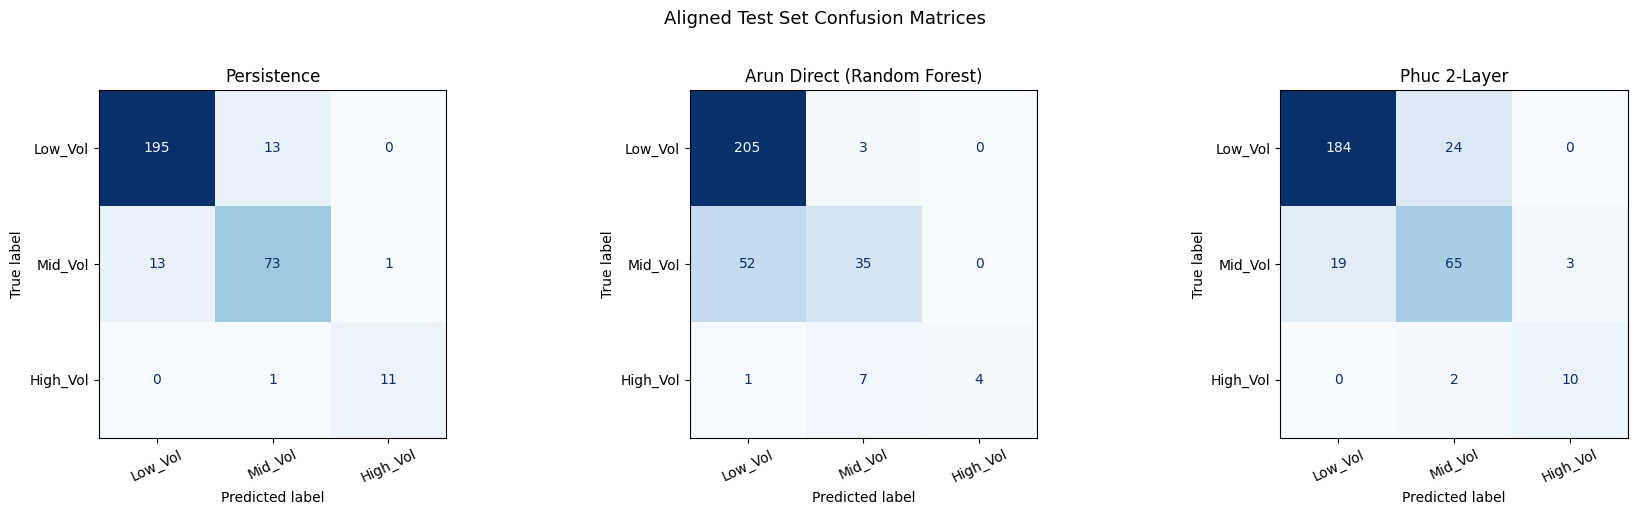

In [29]:
# Confusion Matrices on aligned test overlap

models_to_plot = [
    ("Persistence", persist_test_eval),
    (f"Arun Direct ({arun_best_name})", arun_test_eval),
    ("Phuc 2-Layer", phuc_test_eval),
]

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6 * len(models_to_plot), 5))
if len(models_to_plot) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test_eval, preds, labels=reg_cols)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=reg_cols)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Aligned Test Set Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Save predictions for portfolio notebooks
# Export BOTH validation and test so downstream portfolio notebooks
# can learn allocation on validation and evaluate on test.

# Choose the correct Layer 1 probability series based on selected model
if phuc_l1_name == "Logistic Regression":
    l1_val_risk_prob = pd.Series(pvl, index=y_val.index)
    l1_test_risk_prob = pd.Series(pts, index=y_test.index)
else:
    # Only use these if RF probabilities were explicitly created
    l1_val_risk_prob = pd.Series(np.nan, index=y_val.index)
    l1_test_risk_prob = pd.Series(np.nan, index=y_test.index)

# Validation export
pred_export_val = val.copy()
pred_export_val["dataset_split"] = "validation"

# Actuals
pred_export_val["actual_next_regime"] = val["next_regime"]

# Model outputs
pred_export_val["persistence_pred"] = val["current_regime"]
pred_export_val["arun_pred"] = arun_val_pred.reindex(val.index)
pred_export_val["phuc_2layer_pred"] = final_val
pred_export_val["phuc_2layer_base_pred"] = final_base_val

# Layer-level outputs
pred_export_val["phuc_l1_pred"] = l1_val_pred
pred_export_val["phuc_l2_pred"] = l2_all_val
pred_export_val["phuc_l1_risk_prob"] = l1_val_risk_prob

# Test export
pred_export_test = test.copy()
pred_export_test["dataset_split"] = "test"

# Actuals
pred_export_test["actual_next_regime"] = test["next_regime"]

# Model outputs
pred_export_test["persistence_pred"] = test["current_regime"]
pred_export_test["arun_pred"] = arun_test_pred.reindex(test.index)
pred_export_test["phuc_2layer_pred"] = final_test
pred_export_test["phuc_2layer_base_pred"] = final_base_test

# Layer-level outputs
pred_export_test["phuc_l1_pred"] = l1_test_pred
pred_export_test["phuc_l2_pred"] = l2_all_test
pred_export_test["phuc_l1_risk_prob"] = l1_test_risk_prob

# Combine and save
pred_export = pd.concat([pred_export_val, pred_export_test], axis=0).sort_index()

pred_export.to_parquet("master_supervised_predictions.parquet")

print("Saved: master_supervised_predictions.parquet")
print("\nRows by split:")
print(pred_export["dataset_split"].value_counts())

print("\nDate range:")
print(pred_export.index.min(), "to", pred_export.index.max())

print("\nColumns:")
print(pred_export.columns.tolist())

Saved: master_supervised_predictions.parquet

Rows by split:
dataset_split
test          307
validation    147
Name: count, dtype: int64

Date range:
2017-01-13 00:00:00 to 2026-02-13 00:00:00

Columns:
['SPY_return', 'QQQ_return', 'SPY_momentum_12', 'VIX_change', 'SPY_vol_4', 'SPY_vol_12', 'yield_spread', 'SPY_return_lag1', 'SPY_return_lag2', 'SPY_return_lag3', 'SPY_return_lag4', 'SPY_return_lag5', 'VIX_change_lag1', 'VIX_change_lag2', 'VIX_change_lag3', 'VIX_change_lag4', 'VIX_change_lag5', 'yield_spread_lag1', 'yield_spread_lag2', 'yield_spread_lag3', 'yield_spread_lag4', 'yield_spread_lag5', 'current_regime', 'next_regime', 'target', 'dataset_split', 'actual_next_regime', 'persistence_pred', 'arun_pred', 'phuc_2layer_pred', 'phuc_2layer_base_pred', 'phuc_l1_pred', 'phuc_l2_pred', 'phuc_l1_risk_prob']


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>